In [1]:
import numpy as np
from archive.prod.rds import get_rds_connection
from dotenv import load_dotenv

load_dotenv()

RANDOM_STATE = 42
TOP_10 = ['math.AP','math.CO','math.AG','math.PR','math.NT', 'math.DG','math.DS','math.FA','math.RT','math.GR']
ARXIV_FULL_NAMES = {
    "math.AC": "Commutative Algebra",
    "math.AG": "Algebraic Geometry",
    "math.AP": "Analysis of PDEs",
    "math.AT": "Algebraic Topology",
    "math.CA": "Classical Analysis and ODEs",
    "math.CO": "Combinatorics",
    "math.CT": "Category Theory",
    "math.CV": "Complex Variables",
    "math.DG": "Differential Geometry",
    "math.DS": "Dynamical Systems",
    "math.FA": "Functional Analysis",
    "math.GM": "General Mathematics",
    "math.GN": "General Topology",
    "math.GR": "Group Theory",
    "math.GT": "Geometric Topology",
    "math.HO": "History and Overview",
    "math.IT": "Information Theory",
    "math.KT": "K-Theory and Homology",
    "math.LO": "Logic",
    "math.MG": "Metric Geometry",
    "math.MP": "Mathematical Physics",
    "math.NA": "Numerical Analysis",
    "math.NT": "Number Theory",
    "math.OA": "Operator Algebras",
    "math.OC": "Optimization and Control",
    "math.PR": "Probability",
    "math.QA": "Quantum Algebra",
    "math.RA": "Rings and Algebras",
    "math.RT": "Representation Theory",
    "math.SG": "Symplectic Geometry",
    "math.SP": "Spectral Theory",
    "math.ST": "Statistics Theory",
}

In [2]:
# Gemma raw tex and slogan embeddings
conn = get_rds_connection()
cur = conn.cursor()

cur.execute("""
SELECT
  theorem_id,
  primary_category,
  raw_embedding,
  slogan_embedding
FROM arxiv_sample_10000;
""")

gemma_rows = cur.fetchall()
cur.close()
conn.close()

gemma_theorem_ids = np.array([r[0] for r in gemma_rows])
gemma_cats = np.array([r[1] for r in gemma_rows])
X_raw = np.array([r[2] for r in gemma_rows], dtype=np.float32)
X_slogan = np.array([r[3] for r in gemma_rows], dtype=np.float32)

In [3]:
# Qwen8b embeddings
conn = get_rds_connection()
cur = conn.cursor()

cur.execute("""
SELECT
    s.theorem_id,
    s.primary_category,
    e.embedding
FROM arxiv_sample_10000 s
JOIN theorem_slogan ts
  ON ts.theorem_id = s.theorem_id
 AND ts.prompt_id = 'body-only-v1'
JOIN theorem_embedding_qwen8b e
  ON e.slogan_id = ts.slogan_id;
""")

qwen8b_rows = cur.fetchall()
cur.close()
conn.close()

qwen8b_theorem_ids = np.array([r[0] for r in qwen8b_rows])
qwen8b_cats = np.array([r[1] for r in qwen8b_rows])
X_qwen8b = np.array([r[2] for r in qwen8b_rows], dtype=np.float32)

In [4]:
from sklearn.decomposition import PCA
import umap

def l2_normalize(X, eps=1e-12):
    return X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), eps)

def get_umap(X, random_state):
    X = l2_normalize(X.astype(np.float32))

    X_pca = PCA(
        n_components=0.95,
        random_state=random_state
    ).fit_transform(X)

    X_pca = l2_normalize(X_pca)

    Z = umap.UMAP(
        n_neighbors=30,
        min_dist=0.01,
        metric="cosine",
        random_state=random_state,

    ).fit_transform(X_pca)

    return Z

def compute_centroids(Z, labels, categories):
    centroids = {}
    for cat in categories:
        mask = labels == cat
        centroids[cat] = Z[mask].mean(axis=0)
    return centroids

# Gemma tex UMAP
Z_raw = get_umap(X_raw, RANDOM_STATE)
raw_centroids = compute_centroids(Z_raw, gemma_cats, TOP_10)

# Gemma slogan UMAP
Z_slogan = get_umap(X_slogan, RANDOM_STATE)
slogan_centroids = compute_centroids(Z_slogan, gemma_cats, TOP_10)

# Qwen8b UMAP
Z_qwen8b = get_umap(X_qwen8b, RANDOM_STATE)
qwen8b_centroids = compute_centroids(Z_qwen8b, qwen8b_cats, TOP_10)

C:\Users\sls70\PycharmProjects\MathCopilot\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\sls70\PycharmProjects\MathCopilot\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\sls70\PycharmProjects\MathCopilot\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\sls70\PycharmProjects\MathCopilot\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [15]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "legend.fontsize": 14,
    "axes.facecolor": "white"
})

unique_cats = np.unique(np.concatenate([qwen8b_cats, gemma_cats]))
cmap = plt.colormaps["tab10"]

cat_to_color = {
    cat: cmap(i)
    for i, cat in enumerate(TOP_10)
}

all_x = np.concatenate([Z_raw[:, 0], Z_slogan[:, 0], Z_qwen8b[:, 0]])
all_y = np.concatenate([Z_raw[:, 1], Z_slogan[:, 1], Z_qwen8b[:, 1]])

xlim = (all_x.min() - 0.5, all_x.max() + 4)
ylim = (all_y.min() - 1, all_y.max() + 0.5)

def create_plot(umap, cats, centroids):
    fig, ax = plt.subplots(1, figsize=(5, 5), layout="constrained")

    # Points
    for cat in TOP_10:
        mask = cats == cat
        ax.scatter(
            umap[mask,0],
            umap[mask,1],
            s=10,
            color=cat_to_color[cat],
            alpha=0.5,
            label=ARXIV_FULL_NAMES[cat],
            edgecolors='none'
        )
    # Centroids
    for cat in cats:
        cx, cy = centroids[cat]
        ax.scatter(
            cx, cy,
            marker='X',
            s=100,
            color=cat_to_color[cat],
            edgecolors='black',
            linewidths=0.75,
            zorder=1
        )

    # Styling
    ax.set_xticks([])
    ax.set_yticks([])

    # ax.set_xlim(xlim)
    # ax.set_ylim(ylim)

    ax.legend(
        loc="best",
        markerscale=2,
        fontsize=7,
    )

    return fig


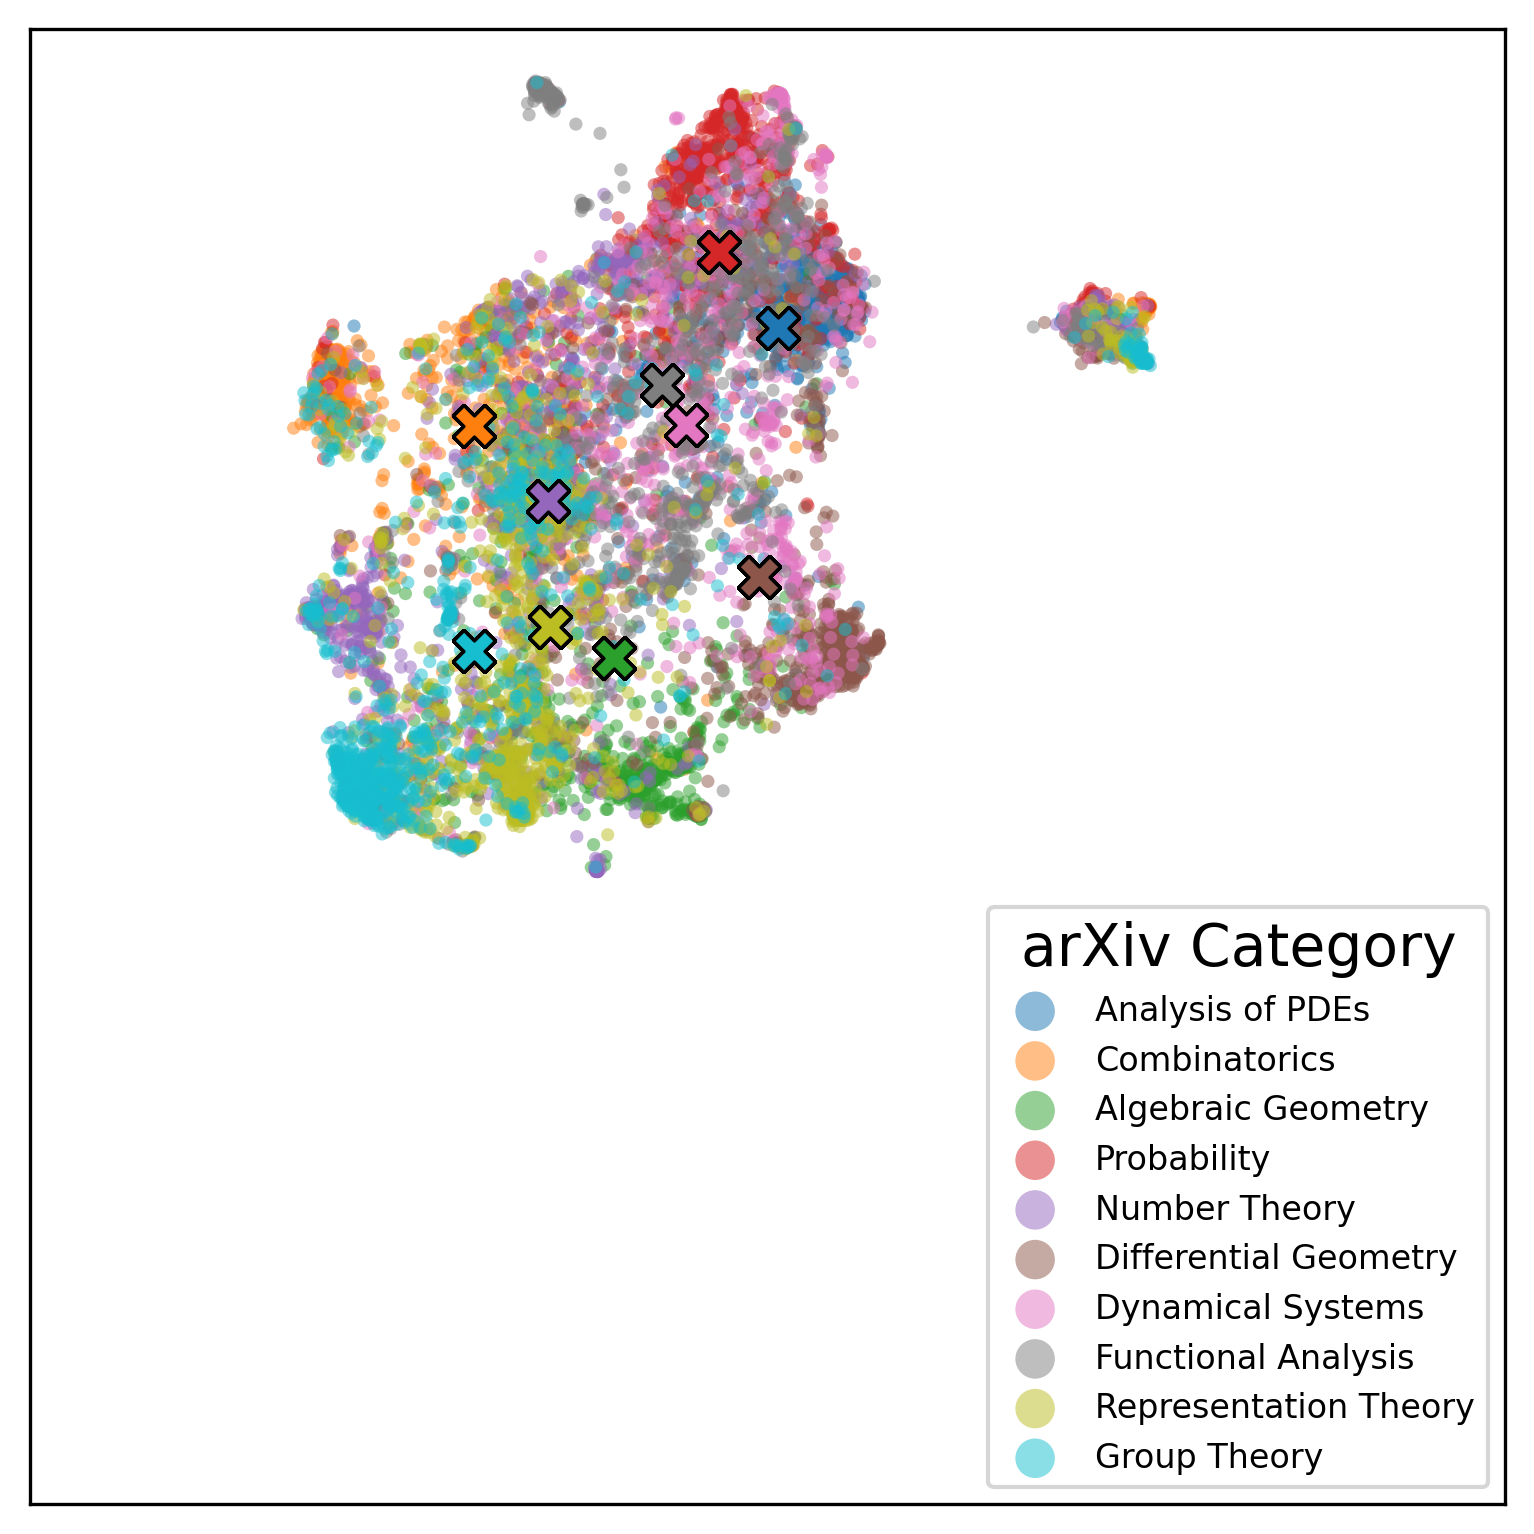

In [6]:
# Gemma tex plot
gemma_tex = create_plot(Z_raw, gemma_cats, raw_centroids)

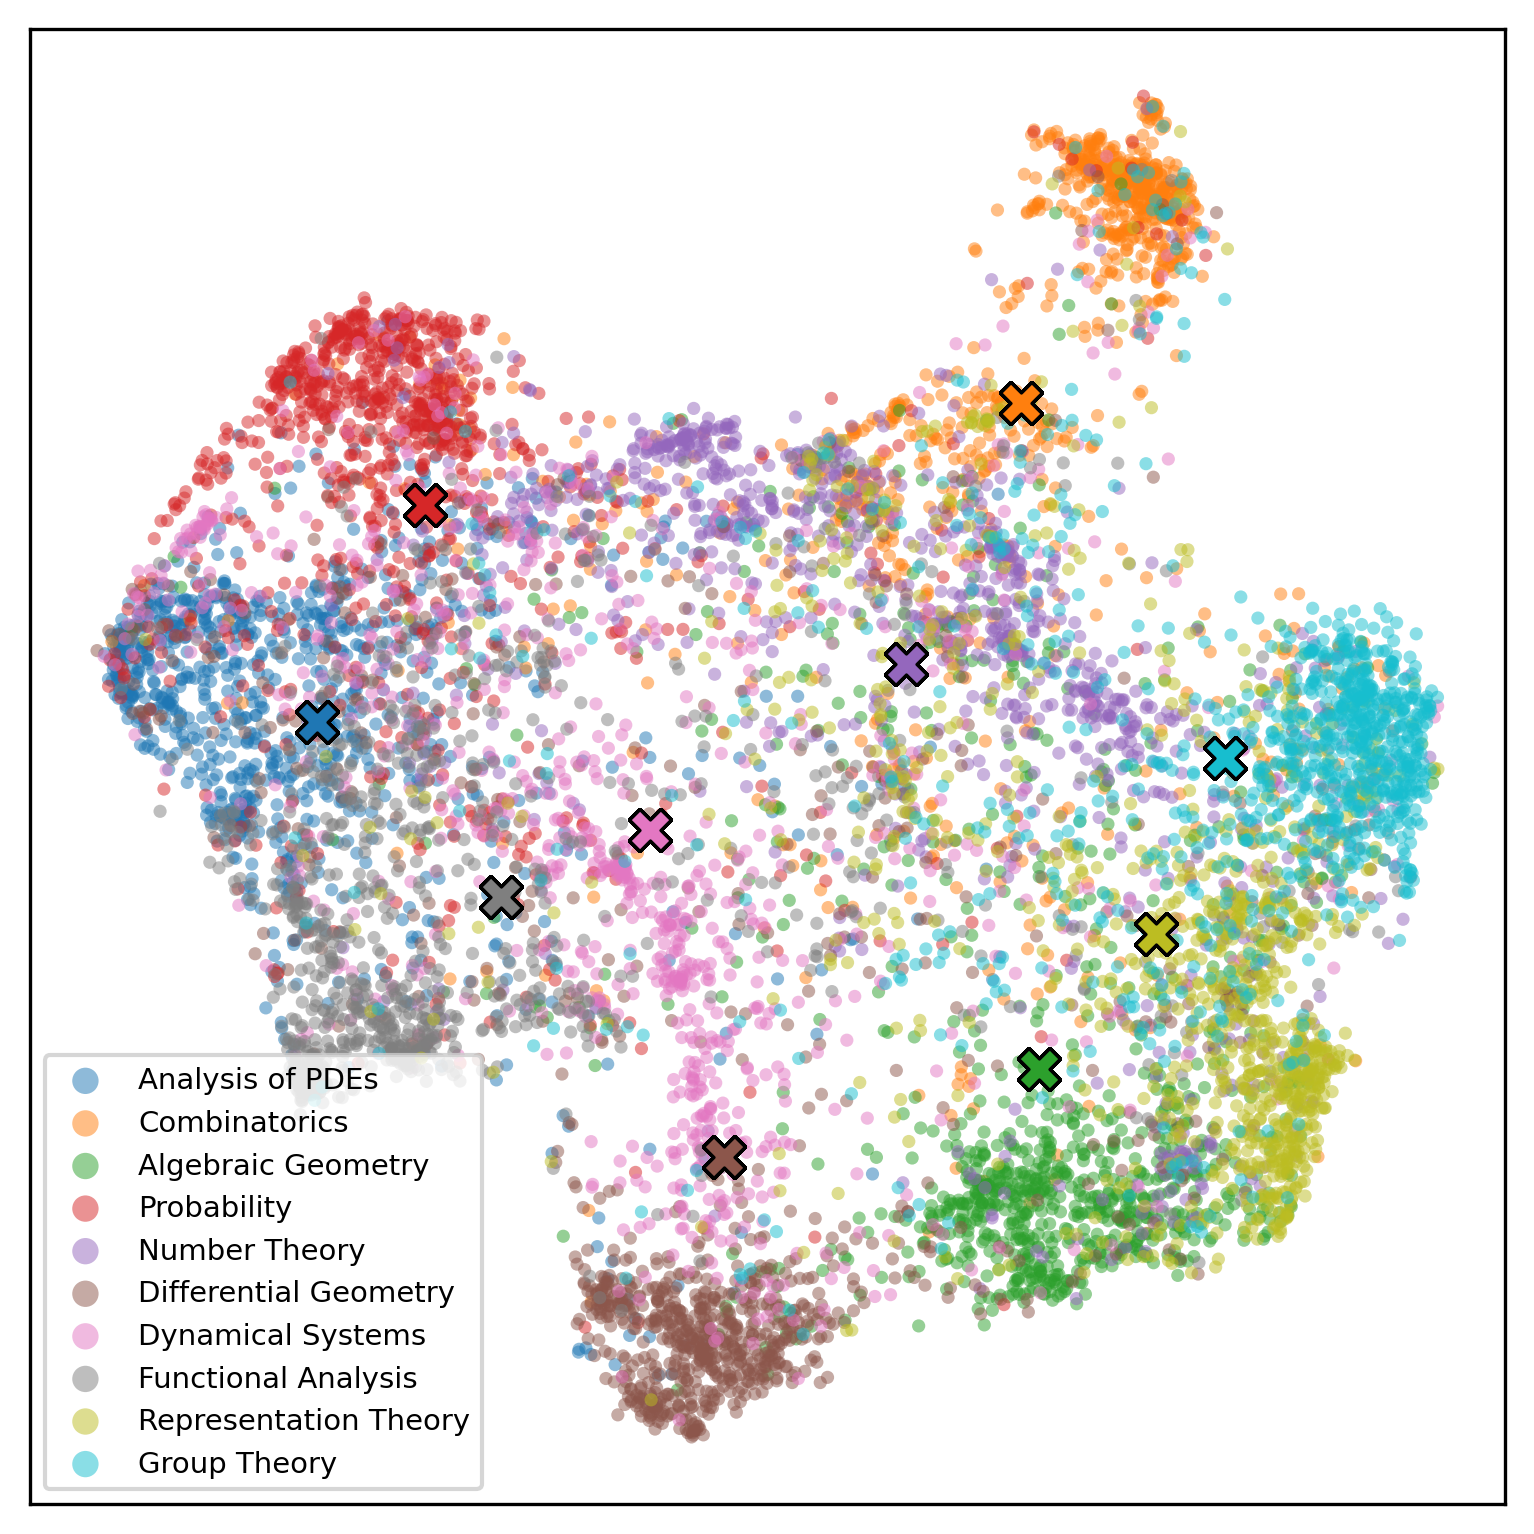

In [16]:
# Gemma slogan plot
gemma_slogan = create_plot(Z_slogan, gemma_cats, slogan_centroids)

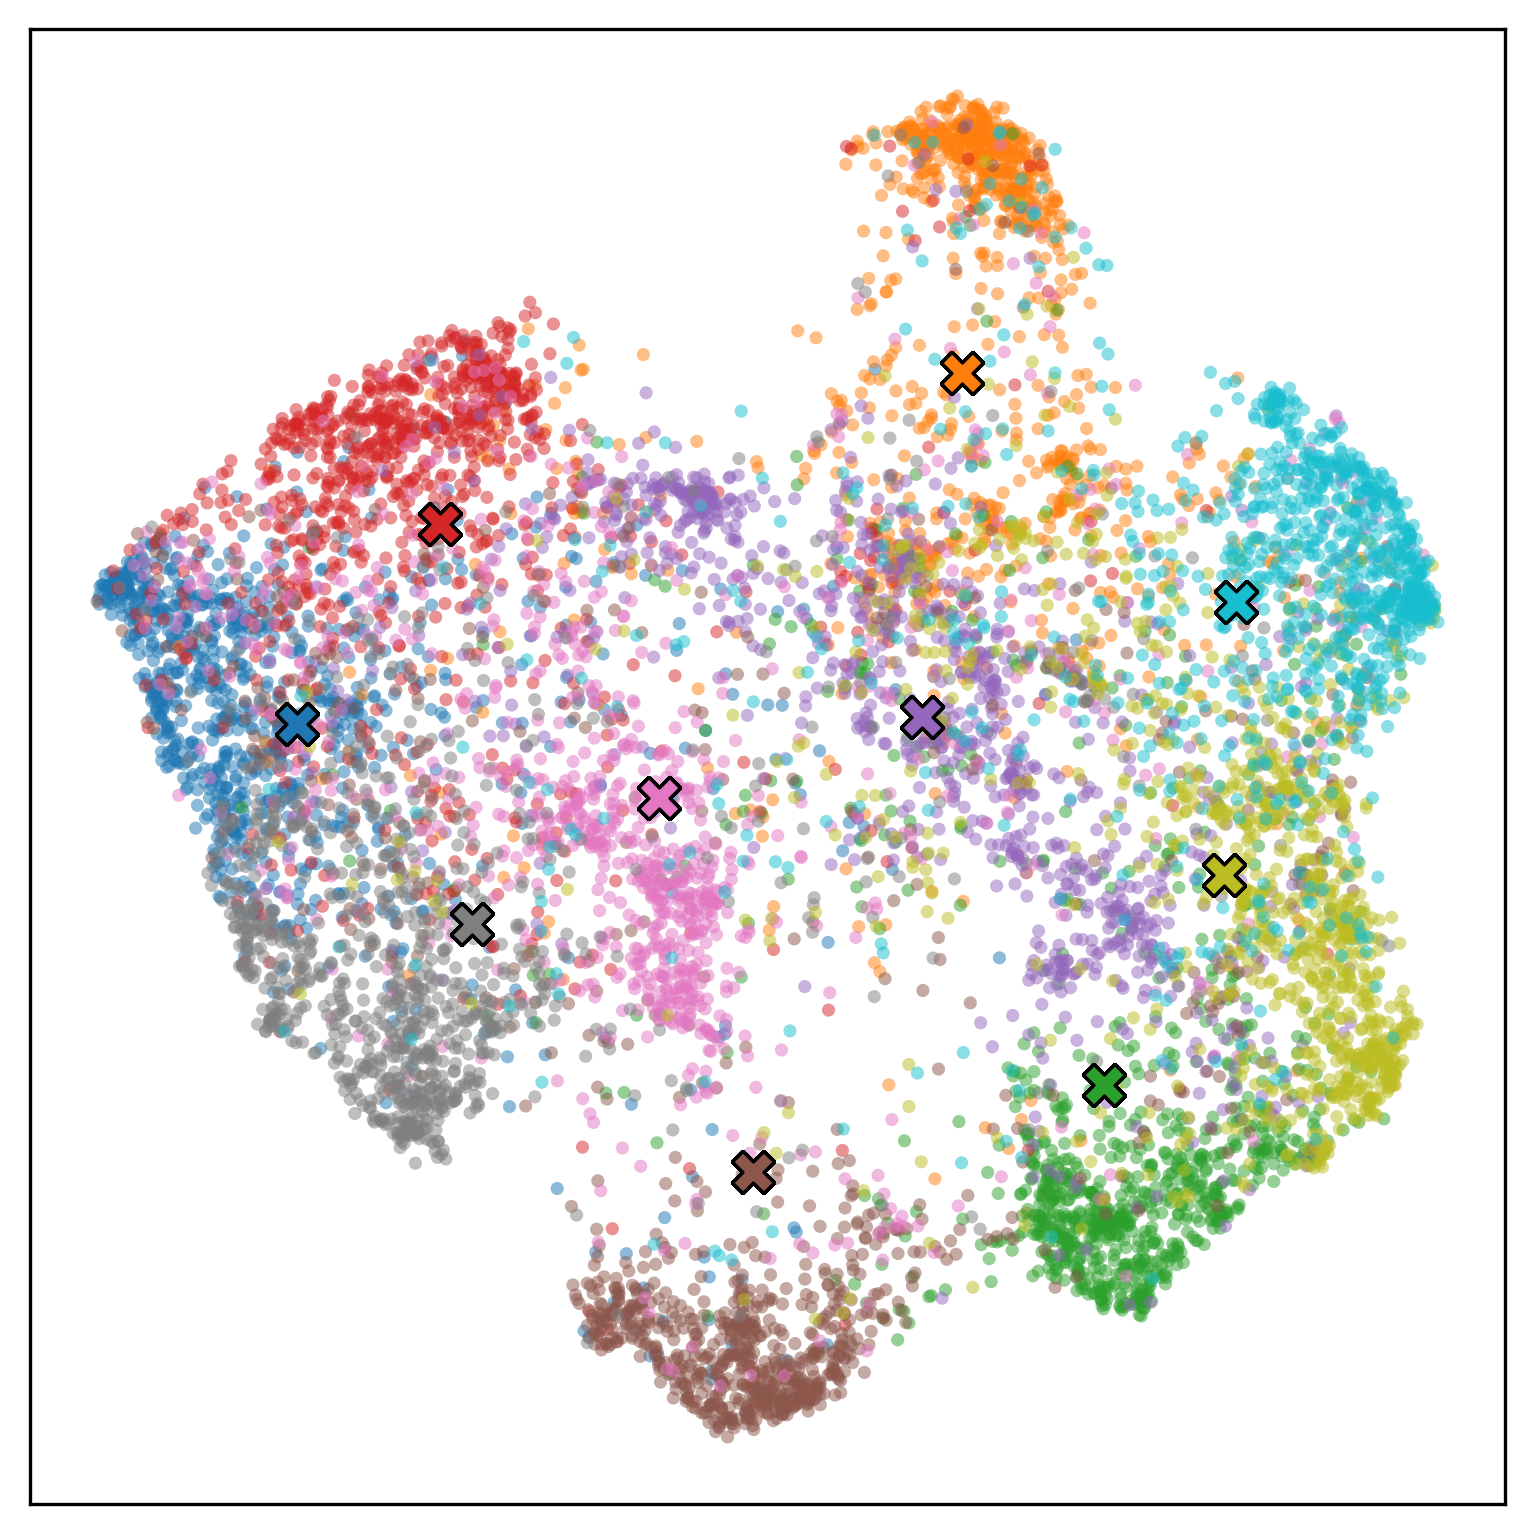

In [16]:
# Qwen8b plot
qwen8b = create_plot(Z_qwen8b, qwen8b_cats, qwen8b_centroids)